## Starting point

We started by writing the 8 questions we will be using to obtain business insight based on the data provided.

1 - Which products are the bestsellers?

2 - What other products do users frequently order with chocolate ?

3 - What aisle and departments have the best selling rate ?

4 - What are the main customer profiles, such as midnight shopper, casual buyer, or cart addict ?

5 - Is there a good timing to send an offer to someone based on the last time he ordered ?

6 - What products should we recommend to a customer ?

7 - Can we predict whether a customer will reorder a given product in their next order ?

8 - Can we predict how many days after their last observed order a customer will purchase a given product again ?

## Imports
First we make all the import we will need in one place to keep the notebook clean and will be adding libraries in this bloc if need be

In [79]:
from copy import deepcopy

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import squarify
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.linear_model import (
    ElasticNet,
    HuberRegressor,
    LinearRegression,
    LogisticRegression,
    Ridge,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from wordcloud import WordCloud

### Import all datasets

In [80]:
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
order_product = pd.read_csv('./datasets/order_products.csv')
orders = pd.read_csv('./datasets/orders.csv')
products = pd.read_csv('./datasets/products.csv')

### Pre data cleaning

In [81]:
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)
orders = orders.dropna()

### Merge datasets

In [82]:
df_merge_a_p = pd.merge(products, aisles, on='aisle_id')
df_merge_a_d_p = df_merge_a_p.merge(departments, on='department_id')
df_merge_a_d_p_ord_pr = order_product.merge(df_merge_a_d_p, on='product_id')
df_merge_a_d_p_order_pr_orders = df_merge_a_d_p_ord_pr.merge(orders, on='order_id')

print(f'Total sell : {df_merge_a_d_p_ord_pr.shape[0]}')

Total sell : 13692437


## Bar plots class

In [83]:
class BarPlot:
    def __init__(
        self,
        df: object,
        columns: list = None,
        title: str = '',
        x_label: str = '',
        y_label: str = '',
        xticks_rotation: int | float = 0,
        horrizontal_aligmnent: str | None = None,
        x_size: int = 10,
        y_size: int = 7,
    ):
        if columns is None:
            columns = []
        self._df = df
        self._columns = columns
        self._fig, self._ax = plt.subplots(figsize=(x_size, y_size))
        self._ax.bar(self._df[self._columns[0]], self._df[self._columns[1]])
        self._ax.set(title=title, xlabel=x_label, ylabel=y_label)
        plt.xticks(rotation=xticks_rotation, ha=horrizontal_aligmnent)
        plt.savefig(f'./assets/{title}')

    def get_plot(self) -> object:
        """
        Get the current bar plot

        ## Parameters
            None

        ## Returns
            Return the current bar plot
        """
        return self._fig

    def save_plot(self, file_name: str | None = None) -> None:
        """
        Save the current plot in a png file

        ## Parameters
            **file_name** : File name to save the plot

        ## Returns
            None
        """

        if not isinstance(file_name, str):
            raise TypeError
        elif not file_name:
            raise ValueError

        self._fig.savefig(file_name)

In [84]:
def TreeMapPlot(
    df: pd.DataFrame, columns: list, title: str, x_size: int = 12, y_size: int = 8
) -> None:
    """
    Generate a treemap plot and save it in assets folder

    # Parameters
        **df** : dataframe containing data
        **columns** : [label_column, value_column]
        **title** : title of the plot
        **x_size** :
        **y_size** :

    # Returns
        None
    """

    labels = [
        f'{label}\n{value:.2f}%'
        for label, value in zip(df[columns[0]], df[columns[1]], strict=False)
    ]

    plt.figure(figsize=(x_size, y_size))

    squarify.plot(sizes=df[columns[1]], label=labels, alpha=0.85, pad=True)

    plt.title(title)

    plt.axis('off')

    plt.tight_layout()

    plt.savefig(f'./assets/{title}.png')

    plt.show()

## 1 - Which products are the bestsellers?

In [85]:
def get_best_sellers() -> object:
    """
    Get the best sellers of the shop

    ## Parameters
        None

    ## Returns
        Best sellers dataframe
    """

    counts_df = order_product['product_id'].value_counts().reset_index()
    counts_df.columns = ['product_id', 'count']
    counts_df = counts_df.merge(products, on='product_id').loc[:, ['count', 'product_name']]

    return counts_df

print(get_best_sellers().head(5))

    count            product_name
0  199654                  Banana
1  160615  Bag of Organic Bananas
2  111975    Organic Strawberries
3  101915    Organic Baby Spinach
4   90372    Organic Hass Avocado


## 2 - What other products do users frequently order with chocolate ?
First we need to merge the product id with the product name to find the chocolate.\
Secondly we need to merge the aisle to target only the chocolate and not only product containing "chocolate" in their name.\

In [86]:
merged_df = products.merge(order_product, on='product_id')

products_full = products.merge(aisles, on='aisle_id')

Next we get the id of the order containing chocolate.

In [87]:
chocolate_products = products_full[
    (products_full['product_name'].str.contains('chocolate', case=False, na=False))
    & (products_full['aisle'].str.contains('candy|chocolate', case=False, na=False))
]

chocolate_ids = chocolate_products['product_id']

chocolate_orders = order_product[order_product['product_id'].isin(chocolate_ids)][
    'order_id'
].unique()

co_products = order_product[order_product['order_id'].isin(chocolate_orders)]

top_products = co_products['product_id'].value_counts().reset_index(name='count')

Then, sort the products and show plot.

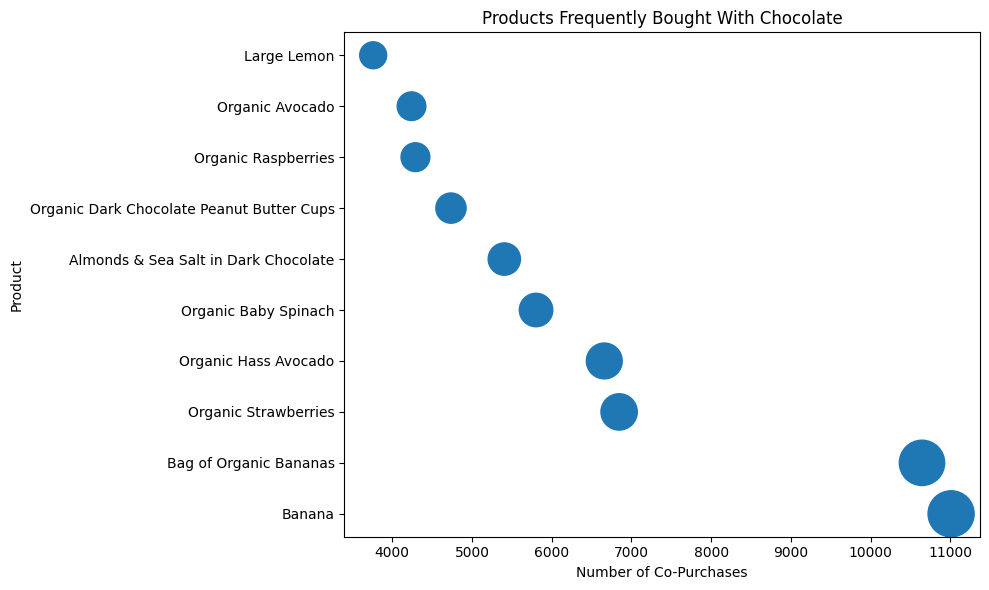

In [88]:
top_products = top_products.merge(products[['product_id', 'product_name']], on='product_id')

top_products = top_products.head(10)


plt.figure(figsize=(10, 6))

plt.scatter(top_products['count'], top_products['product_name'], s=top_products['count'] / 10)

plt.title('Products Frequently Bought With Chocolate')
plt.xlabel('Number of Co-Purchases')
plt.ylabel('Product')

plt.tight_layout()

plt.savefig('./assets/Chocolate Co-Purchase Bubble.png')
plt.show()

The co-purchase analysis reveals that chocolate is frequently bought alongside everyday grocery staples rather than only dessert products.

Bananas and bags of organic bananas appear as the strongest associations, suggesting that chocolate purchases often occur within larger routine grocery baskets rather than impulse snack purchases alone.

Fresh produce such as strawberries, avocados, raspberries and spinach also appear frequently. This indicates that customers tend to buy chocolate during regular grocery shopping trips that include healthy items.

Some chocolate-related products (such as dark chocolate peanut butter cups or chocolate bars) also appear in the list, suggesting that customers occasionally purchase multiple chocolate products in the same basket.

Overall, chocolate purchases are strongly integrated into general grocery shopping behavior rather than isolated snack purchases. This insight can help retailers design cross-category promotions combining indulgent products with everyday essentials.

## 3 - What aisle and departments have the best selling rate ?

In [89]:
def aisles_dep_selling_rate(grp_type: str = 'department', n: int = 10) -> object:
    """
    Get aisles/departments selling rate.

    # Parameters
        **grp_type** : Aisle / Department (case insensitive)
        **n** : Maximum number of returned rows

    # Returns
        Dataframe with 2 columns : Aisle/Department and Selling rate
    """

    if not isinstance(grp_type, str) or not isinstance(n, int):
        raise TypeError
    elif grp_type != 'department' and grp_type != 'aisle':
        raise ValueError

    grp_type = grp_type.lower()

    df_dep_count = (
        df_merge_a_d_p_ord_pr.groupby(grp_type)
        .size()
        .reset_index(name='selling rate')
        .sort_values(by='selling rate', ascending=False)
        .reset_index(drop=True)
        .head(10)
    )
    df_dep_count['selling rate'] = (
        df_dep_count['selling rate'] / df_merge_a_d_p_ord_pr.shape[0]
    ) * 100

    return df_dep_count

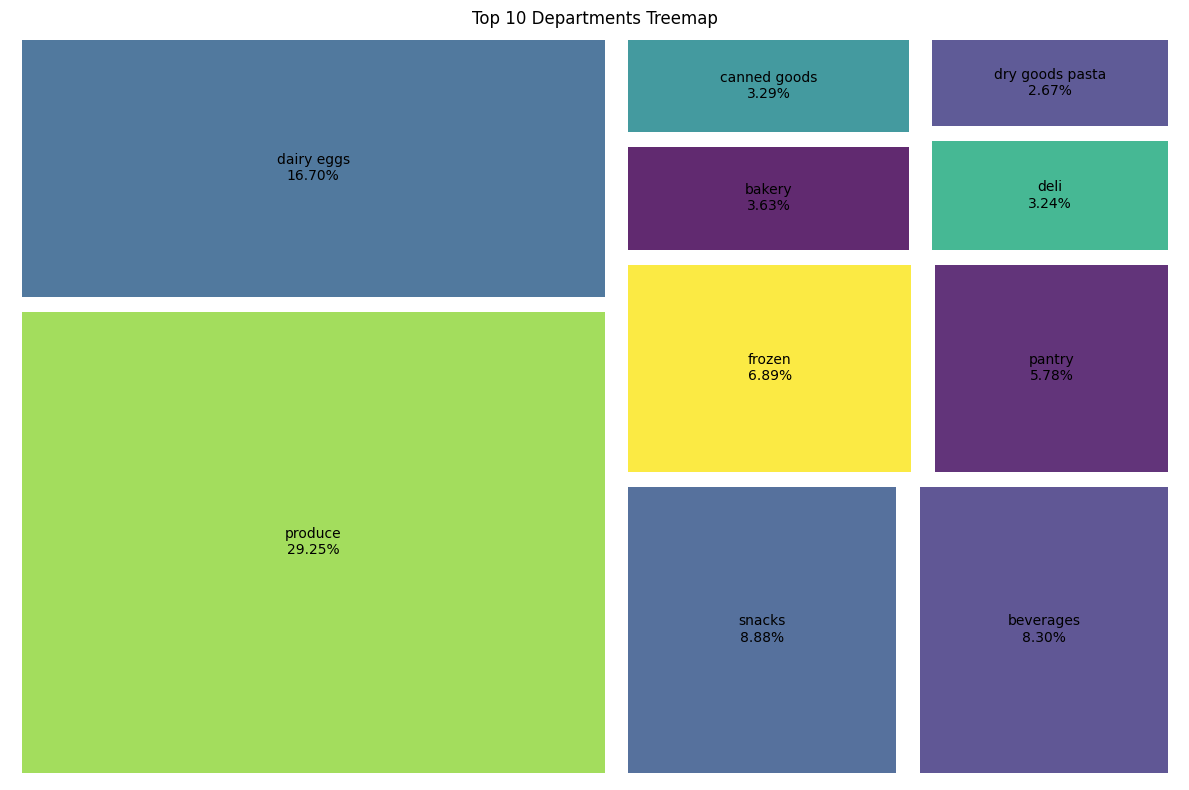

In [90]:
df_deps_stats = aisles_dep_selling_rate('department', 10)

TreeMapPlot(df_deps_stats, ['department', 'selling rate'], 'Top 10 Departments Treemap')

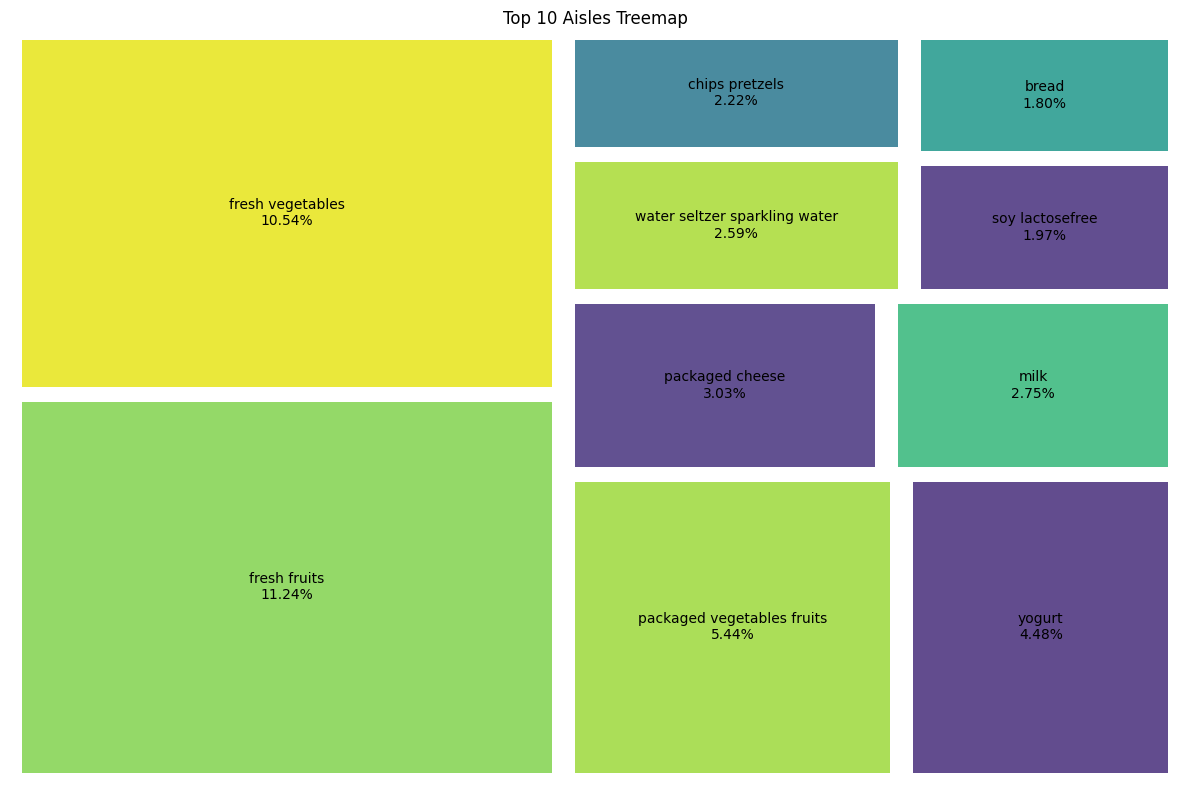

In [91]:
df_aisles_stats = aisles_dep_selling_rate('aisle', 10)

TreeMapPlot(df_aisles_stats, ['aisle', 'selling rate'], 'Top 10 Aisles Treemap')

# 4 - What are the main customer profiles, such as midnight shopper, casual buyer, or cart addict?

In [92]:
# First we make a copy of the orders dataset and replace missing values
orders = orders.copy()
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)

# Then we calculate the size of each cart by counting the number of products in every order
order_sizes = order_product.groupby('order_id').size().reset_index(name='cart_size')

# Next we merge the cart size with the orders dataframe to get the user information
orders_full = orders.merge(order_sizes, on='order_id')

In [93]:
# After that we aggregate the data by user to obtain global statistics for each customer
user_stats = (
    orders_full.groupby('user_id')
    .agg(
        {
            'order_id': 'count',
            'cart_size': 'mean',
            'days_since_prior_order': 'mean',
            'order_hour_of_day': 'mean',
        }
    )
    .reset_index()
)

# Then we rename the columns to make the dataframe easier to read
user_stats.columns = [
    'user_id',
    'total_orders',
    'avg_cart_size',
    'avg_days_between_orders',
    'avg_order_hour',
]

In [94]:
# Next we define a function that assigns a single profile to each user based on simple behavioral rules
def define_profile(row: int):
    """
    Get customer profile (such as midnight_shopper, cart_addict, casual_buyer or regular_customer)

    # Parameters
        **row** : Number of customer orders

    # Returns
        Profile name
    """
    if row['avg_order_hour'] <= 5:
        return 'midnight_shopper'
    elif row['avg_cart_size'] > 20:
        return 'cart_addict'
    elif row['avg_days_between_orders'] > 25:
        return 'casual_buyer'
    else:
        return 'regular_customer'


# Finally we apply the function to assign a profile to every user
user_stats['profile'] = user_stats.apply(define_profile, axis=1)

print(user_stats['profile'].value_counts())

profile
regular_customer    168361
casual_buyer         14740
cart_addict          13468
midnight_shopper       792
Name: count, dtype: int64


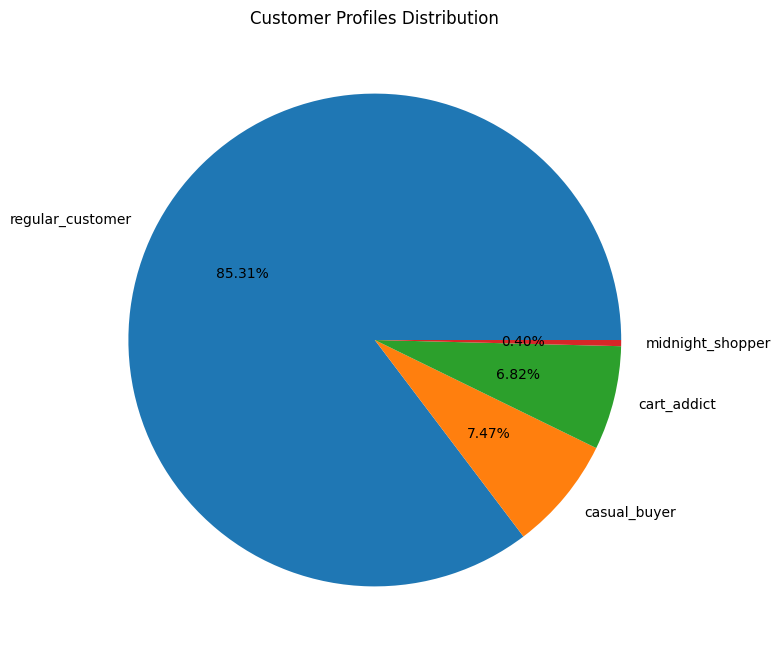

In [95]:
# First we count how many users belong to each profile
profile_counts = user_stats['profile'].value_counts()

# Then we create a pie chart to visualize the distribution of customer profiles
plt.figure(figsize=(8, 8))
plt.pie(profile_counts, labels=profile_counts.index, autopct='%1.2f%%')

plt.title('Customer Profiles Distribution')
plt.savefig(f'./assets/{"Customer Profiles Distribution"}')
plt.show()

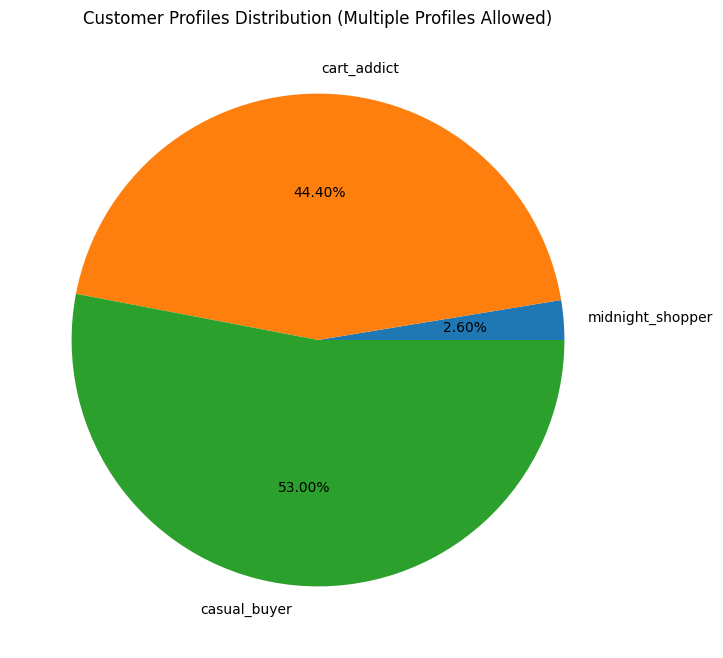

In [96]:
# First we create boolean columns for each profile rule
user_stats['midnight_shopper'] = user_stats['avg_order_hour'] <= 5
user_stats['cart_addict'] = user_stats['avg_cart_size'] > 20
user_stats['casual_buyer'] = user_stats['avg_days_between_orders'] > 25

# Then we count how many users match each profile
multi_profile_counts = {
    'midnight_shopper': user_stats['midnight_shopper'].sum(),
    'cart_addict': user_stats['cart_addict'].sum(),
    'casual_buyer': user_stats['casual_buyer'].sum(),
}

# Next we convert the result to a pandas series for plotting
multi_profile_counts = pd.Series(multi_profile_counts)

# Finally we create a pie chart showing the overlap between profiles
plt.figure(figsize=(8, 8))
plt.pie(multi_profile_counts, labels=multi_profile_counts.index, autopct='%1.2f%%')

plt.title('Customer Profiles Distribution (Multiple Profiles Allowed)')
plt.savefig(f'./assets/{"Customer Profiles Distribution (Multiple Profiles Allowed)"}')
plt.show()

The customer segmentation highlights different purchasing behaviors.<br>

-Casual buyers represent a large portion of the customer base, meaning that many users order infrequently and may benefit from re-engagement strategies.<br>

-Cart addicts, although fewer, represent high-value customers due to their large basket sizes.<br>

-Midnight shoppers reveal specific ordering habits that could be targeted with time-based promotions.<br>

Understanding these profiles allows the platform to personalize recommendations and marketing strategies.<br>

# 5 - Is there a good timing to send an offer to someone based on the last time he ordered

In [97]:
# First we select the column that indicates the number of days since the previous order
days_between_orders = orders['days_since_prior_order']

# Then we remove missing values because the first order of a user does not have a previous order
days_between_orders = days_between_orders.dropna()

# Next we count how many times each delay appears
reorder_distribution = days_between_orders.value_counts().sort_index().reset_index()

# Then we rename the columns to make the dataframe easier to read
reorder_distribution.columns = ['days_since_last_order', 'count']

print(reorder_distribution.head())

   days_since_last_order   count
0                    0.0  115742
1                    1.0   61303
2                    2.0   81465
3                    3.0   91805
4                    4.0   93814


In [98]:
# First we calculate the total number of recorded delays
total_orders = reorder_distribution['count'].sum()

# Then we compute the probability for each delay
reorder_distribution['probability'] = reorder_distribution['count'] / total_orders

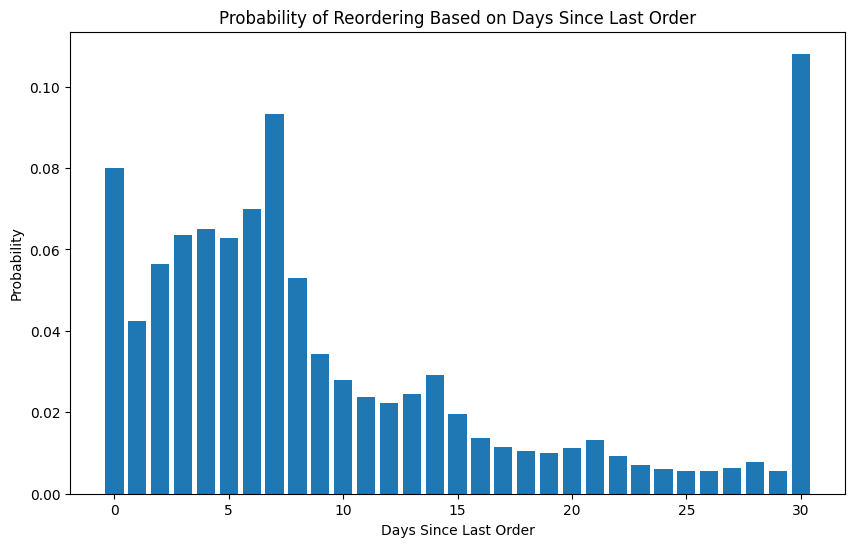

In [99]:
# Finally we create a bar chart to visualize the probability of reordering depending on the delay
reorder_probability_plot = BarPlot(
    reorder_distribution,
    ['days_since_last_order', 'probability'],
    'Probability of Reordering Based on Days Since Last Order',
    'Days Since Last Order',
    'Probability',
    0,
    'center',
    10,
    6,
)

## 6 - What products should we recommend to a customer?

In [100]:
def show_word_cloud(lst: list[str], width: int = 480, height: int = 480, margin: int = 0) -> None:
    """
    Show word cloud with custom words

    # Parameters
        **lst** : List of choosen words
        **width** : Width of the word cloud figure
        **height** : Height of the word cloud figure
        **margin** : Margin of the word cloud figure

    # Returns
        None
    """

    text = ' '.join(lst)
    word_cloud = WordCloud(width=width, height=height, margin=margin).generate(text)
    plt.imshow(word_cloud, interpolation='bilinear')
    plt.axis('off')
    plt.margins(x=0, y=0)
    plt.show()

    return None

### Case 1 : Global recommendations

Promote the 5 best sellers.

    count            product_name
0  199654                  Banana
1  160615  Bag of Organic Bananas
2  111975    Organic Strawberries
3  101915    Organic Baby Spinach
4   90372    Organic Hass Avocado


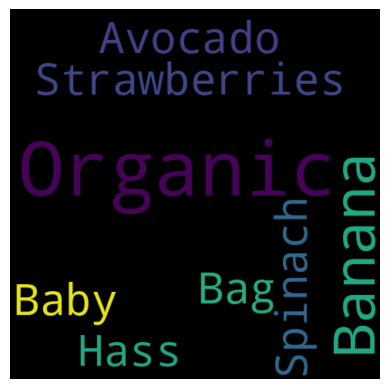

In [101]:
def get_best_sellers() -> object:
    """
    Get the best sellers of the shop

    ## Parameters
        None

    ## Returns
        Best sellers dataframe
    """

    counts_df = order_product['product_id'].value_counts().reset_index()
    counts_df.columns = ['product_id', 'count']
    counts_df = counts_df.merge(products, on='product_id').loc[:, ['count', 'product_name']]

    return counts_df


top_5_best_sellers = get_best_sellers().head(5)
print(top_5_best_sellers)

show_word_cloud(get_best_sellers().head(5)['product_name'].to_list())

### Case 2 : Product page recommandations

Promote the n best sellers who are ordered with a specified product.

In [102]:
def get_reco_product(
    product_name: str, n: int = 3, percent: int | float | None = None
) -> list[str]:
    """
    Get the most ordered products in the same 'product_name' order

    ## Parameters
        **product_name** : Product name (case insensitive)
        **n** : Maximum amount of returned products (positive number)
        **percent** : Minimum order rate of returned products

    ## Returns
        List of most ordered products in the same 'product_name' order
    """

    if not isinstance(product_name, str) or not isinstance(n, int):
        raise TypeError
    elif not product_name:
        raise ValueError

    reco = []

    orders_id_with_product = df_merge_a_d_p_ord_pr[
        df_merge_a_d_p_ord_pr['product_name'] == product_name
    ]['order_id']

    reco_global = df_merge_a_d_p_ord_pr[
        (df_merge_a_d_p_ord_pr['product_name'] != product_name)
        & (df_merge_a_d_p_ord_pr['product_id'].isin(orders_id_with_product))
    ]

    reco_global = (
        reco_global.groupby('product_name')
        .size()
        .sort_values(ascending=False)
        .reset_index(name='count')
    )
    reco_global_head = reco_global.head(n)

    if percent is not None:
        reco_global_head['rate'] = (reco_global['count'] / reco_global['count'].sum()) * 100
        reco_global_head = reco_global_head[reco_global_head['rate'] >= percent]
        reco.extend(reco_global_head['product_name'].to_list())
    else:
        reco.extend(reco_global_head['product_name'].to_list())

    return reco

"Wheat Chex Cereal" often bought with : 

   -Simply Clean Fragrance Free Wipes
   -Cookies 'N Cream Protein Bar
   -Organic Chocolate O's Cereal


/tmp/ipykernel_34757/1488045331.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reco_global_head['rate'] = (reco_global['count'] / reco_global['count'].sum()) * 100


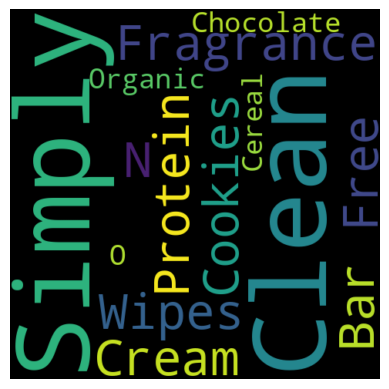

In [103]:
product_name = 'Wheat Chex Cereal'
reco_product = get_reco_product(product_name, n=4, percent=6)

print(f'"{product_name}" often bought with : \n\n   -{"\n   -".join(reco_product)}')

show_word_cloud(reco_product)

# Machine learning

### Split old orders and last orders

In [104]:
latest_orders_index = (
    orders.groupby('user_id')['order_number'].idxmax().reset_index(name='latest_order_index')
)

old_orders = orders[~orders.index.isin(latest_orders_index['latest_order_index'])].copy()
last_order = orders[orders.index.isin(latest_orders_index['latest_order_index'])].copy()

#### Data cleaning

In [105]:
old_orders = old_orders.dropna(subset=['order_id', 'user_id', 'order_number'])

In [106]:
old_order_products = order_product[order_product['order_id'].isin(old_orders['order_id'])].copy()
last_order_products = order_product[order_product['order_id'].isin(last_order['order_id'])].copy()

df_old_merge_a_d_p_ord_pr = old_order_products.merge(df_merge_a_d_p, on='product_id')
df_old_merge_a_d_p_order_pr_orders = df_old_merge_a_d_p_ord_pr.merge(old_orders, on='order_id')

### Prepare features

In [107]:
df_old_merge_a_d_p_order_pr_orders_copy = (
    df_old_merge_a_d_p_order_pr_orders.copy()
)  # merged aisles + departments + products + orders

**[user_product_count]** : number of times the customer has already purchased the product \
**[aisle_id]** aisle id of the product \
**[department_id]** department id of the product

In [108]:
df_client_product = (
    df_old_merge_a_d_p_order_pr_orders_copy.groupby(
        ['user_id', 'product_id', 'aisle_id', 'department_id']
    )
    .size()
    .reset_index(name='user_product_count')
)

**[user_total_orders]** : total number of customer orders

In [109]:
df_client_product = df_client_product.merge(
    old_orders.groupby('user_id')['order_id'].nunique().reset_index(name='user_total_orders'),
    on='user_id',
)

**[user_product_order_ratio]** : percentage of the customer's orders containing this product

In [110]:
df_client_product['user_product_order_ratio'] = (
    df_client_product['user_product_count'] / df_client_product['user_total_orders']
)

**[orders_since_last_purchase]** : number of orders since the last purchase

In [111]:
df_merge_ord_pr_orders_copy = (
    df_old_merge_a_d_p_order_pr_orders.copy()
    .sort_values(['user_id', 'order_number'])
    .reset_index(drop=True)
)
df_merge_ord_pr_orders_copy['last_order_number'] = df_merge_ord_pr_orders_copy.groupby('user_id')[
    'order_number'
].transform('max')
df_merge_ord_pr_orders_copy['last_product_order_number'] = df_merge_ord_pr_orders_copy.groupby(
    ['user_id', 'product_id']
)['order_number'].transform('max')
df_merge_ord_pr_orders_copy['orders_since_last_purchase'] = (
    df_merge_ord_pr_orders_copy['last_order_number']
    - df_merge_ord_pr_orders_copy['last_product_order_number']
)
df_merge_ord_pr_orders_copy = (
    df_merge_ord_pr_orders_copy.groupby(['user_id', 'product_id'])['orders_since_last_purchase']
    .first()
    .reset_index(name='orders_since_last_purchase')
)

df_client_product = df_client_product.merge(
    df_merge_ord_pr_orders_copy[['user_id', 'product_id', 'orders_since_last_purchase']],
    on=['user_id', 'product_id'],
)

**[avg_add_to_cart_order]** : average position in the basket

In [112]:
df_avg_add_to_cart_order = df_old_merge_a_d_p_order_pr_orders.copy()
df_avg_add_to_cart_order = (
    df_avg_add_to_cart_order.groupby(['user_id', 'product_id'])['add_to_cart_order']
    .mean()
    .reset_index(name='avg_add_to_cart_order')
)

df_client_product = df_client_product.merge(
    df_avg_add_to_cart_order[['user_id', 'product_id', 'avg_add_to_cart_order']],
    on=['user_id', 'product_id'],
)

**[avg_basket_size]** : average customer basket size

In [113]:
df_avg_basket_size = old_order_products.copy()

df_avg_basket_size = df_avg_basket_size.groupby('order_id').size().reset_index(name='basket_size')
df_avg_basket_size = df_avg_basket_size.merge(old_orders[['order_id', 'user_id']], on='order_id')
df_avg_basket_size = (
    df_avg_basket_size.groupby('user_id')['basket_size'].mean().reset_index(name='avg_basket_size')
)

df_client_product = df_client_product.merge(
    df_avg_basket_size[['user_id', 'avg_basket_size']], on='user_id'
)

**[avg_days_between_user_product_orders]** : average time between purchases of this product

In [114]:
df_avg_days_btwn_usr_pr_ords = old_orders.copy()

df_avg_days_btwn_usr_pr_ords = df_avg_days_btwn_usr_pr_ords.sort_values(['user_id', 'order_number'])
df_avg_days_btwn_usr_pr_ords['cumulative_days'] = df_avg_days_btwn_usr_pr_ords.groupby('user_id')[
    'days_since_prior_order'
].cumsum()
df_avg_days_btwn_usr_pr_ords = df_avg_days_btwn_usr_pr_ords.merge(
    old_order_products, on='order_id'
)[['user_id', 'product_id', 'order_id', 'cumulative_days']].sort_values(
    ['user_id', 'product_id', 'cumulative_days']
)
df_avg_days_btwn_usr_pr_ords['days_between'] = df_avg_days_btwn_usr_pr_ords.groupby(
    ['user_id', 'product_id']
)['cumulative_days'].diff()
df_avg_days_btwn_usr_pr_ords = (
    df_avg_days_btwn_usr_pr_ords.groupby(['user_id', 'product_id'])['days_between']
    .mean()
    .reset_index(name='avg_days_between_user_product_orders')
)
df_avg_days_btwn_usr_pr_ords['has_multiple_purchases'] = ~df_avg_days_btwn_usr_pr_ords[
    'avg_days_between_user_product_orders'
].isna()
df_avg_days_btwn_usr_pr_ords['avg_days_between_user_product_orders'] = df_avg_days_btwn_usr_pr_ords[
    'avg_days_between_user_product_orders'
].fillna(-1)

df_client_product = df_client_product.merge(
    df_avg_days_btwn_usr_pr_ords[
        ['user_id', 'product_id', 'avg_days_between_user_product_orders', 'has_multiple_purchases']
    ],
    on=['user_id', 'product_id'],
)

**[avg_order_hour_for_user_product]** : average time of purchase

In [115]:
df_avg_ordr_hour_for_user_pr = old_orders.copy()

df_avg_ordr_hour_for_user_pr = df_avg_ordr_hour_for_user_pr.merge(old_order_products, on='order_id')
df_avg_ordr_hour_for_user_pr = (
    df_avg_ordr_hour_for_user_pr.groupby(['user_id', 'product_id'])['order_hour_of_day']
    .mean()
    .reset_index(name='df_avg_ordr_hour_for_user_pr')
)

df_client_product = df_client_product.merge(
    df_avg_ordr_hour_for_user_pr[['user_id', 'product_id', 'df_avg_ordr_hour_for_user_pr']],
    on=['user_id', 'product_id'],
)

**[user_avg_days_between_orders]** : average time between customer orders

In [116]:
df_avg_days_between_orders_copy = old_orders.copy()

df_avg_days_between_orders_copy = df_avg_days_between_orders_copy.sort_values(
    ['user_id', 'order_number']
)
df_avg_days_between_orders_copy['cumulative_days'] = df_avg_days_between_orders_copy.groupby(
    'user_id'
)['days_since_prior_order'].cumsum()
df_avg_days_between_orders_copy = df_avg_days_between_orders_copy.merge(
    order_product, on='order_id'
)[['user_id', 'order_id', 'cumulative_days']].sort_values(['user_id', 'cumulative_days'])
df_avg_days_between_orders_copy['days_between'] = df_avg_days_between_orders_copy.groupby(
    ['user_id']
)['cumulative_days'].diff()
df_avg_days_between_orders_copy = (
    df_avg_days_between_orders_copy.groupby(['user_id'])['days_between']
    .mean()
    .reset_index(name='user_avg_days_between_orders')
)

df_client_product = df_client_product.merge(
    df_avg_days_between_orders_copy[['user_id', 'user_avg_days_between_orders']], on=['user_id']
)

**[product_reorder_ratio]** : overall product reorder rate

In [117]:
df_product_reorder_rate = old_orders.copy().merge(order_product, on='order_id')

df_product_reorder_rate = (
    df_product_reorder_rate.groupby(['user_id', 'product_id']).size().reset_index(name='count')
)

df_temp_user_bought = (
    df_product_reorder_rate.groupby('product_id')['user_id']
    .nunique()
    .reset_index(name='user_bought')
)
df_temp_user_reordered = (
    df_product_reorder_rate[df_product_reorder_rate['count'] > 1]
    .groupby('product_id')['user_id']
    .nunique()
    .reset_index(name='user_reordered')
)
df_temp_user_reordered_rate = df_temp_user_reordered.merge(df_temp_user_bought, on='product_id')
df_temp_user_reordered_rate['product_reorder_ratio'] = (
    df_temp_user_reordered_rate['user_reordered'] / df_temp_user_reordered_rate['user_bought']
)

df_client_product = df_client_product.merge(
    df_temp_user_reordered_rate[['product_id', 'product_reorder_ratio']], on='product_id'
)

**[product_total_purchases_ratio]** : product global popularity

In [118]:
df_product_total_purchases = old_order_products.copy()

df_product_total_purchases = (
    df_product_total_purchases.groupby('product_id')
    .size()
    .reset_index(name='product_total_purchases')
)
df_product_total_purchases['product_total_purchases_ratio'] = (
    df_product_total_purchases['product_total_purchases']
    / df_product_total_purchases['product_total_purchases'].sum()
)

df_client_product = df_client_product.merge(
    df_product_total_purchases[['product_id', 'product_total_purchases_ratio']], on='product_id'
)

### Final convertions

In [119]:
list_to_convert = [
    'user_id',
    'aisle_id',
    'department_id',
    'product_id',
    'user_product_count',
    'user_total_orders',
    'orders_since_last_purchase',
]
for column in list_to_convert:
    df_client_product[column] = df_client_product[column].astype(int)

print(df_client_product.info(), end='\n------------------\n')
print(df_client_product.head(), end='\n------------------\n')
print(df_client_product.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6906739 entries, 0 to 6906738
Data columns (total 16 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   user_id                               int64  
 1   product_id                            int64  
 2   aisle_id                              int64  
 3   department_id                         int64  
 4   user_product_count                    int64  
 5   user_total_orders                     int64  
 6   user_product_order_ratio              float64
 7   orders_since_last_purchase            int64  
 8   avg_add_to_cart_order                 float64
 9   avg_basket_size                       float64
 10  avg_days_between_user_product_orders  float64
 11  has_multiple_purchases                bool   
 12  df_avg_ordr_hour_for_user_pr          float64
 13  user_avg_days_between_orders          float64
 14  product_reorder_ratio                 float64
 15  product_total_p

## 7 - Can we predict whether a customer will reorder a given product in their next order?

### 7.1 - **Target**

```1``` the product is in the last order of the customer \
```0``` the product is not in the last order of the customer

In [120]:
df_target = last_order.merge(last_order_products, on='order_id')
df_target = df_target[['user_id', 'product_id']].drop_duplicates()
df_target['target'] = 1

df_client_product = df_client_product.merge(df_target, how='left', on=['user_id', 'product_id'])
df_client_product['target'].fillna(0, inplace=True)
df_client_product['target'] = df_client_product['target'].astype(int)

### 7.2 - **Preview of training dataset, target rate**

In [121]:
df_client_product['target'].value_counts(normalize=True)

print(
    df_client_product.info(),
    df_client_product.head(),
    df_client_product.tail(),
    df_client_product.describe(),
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6906739 entries, 0 to 6906738
Data columns (total 17 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   user_id                               int64  
 1   product_id                            int64  
 2   aisle_id                              int64  
 3   department_id                         int64  
 4   user_product_count                    int64  
 5   user_total_orders                     int64  
 6   user_product_order_ratio              float64
 7   orders_since_last_purchase            int64  
 8   avg_add_to_cart_order                 float64
 9   avg_basket_size                       float64
 10  avg_days_between_user_product_orders  float64
 11  has_multiple_purchases                bool   
 12  df_avg_ordr_hour_for_user_pr          float64
 13  user_avg_days_between_orders          float64
 14  product_reorder_ratio                 float64
 15  product_total_p

### 7.3 - **Search last NaN values**

In [122]:
X = df_client_product.drop(['user_id', 'product_id', 'target'], axis=1).copy()
y = df_client_product['target'].copy()

print(X.isna().sum())

aisle_id                                   0
department_id                              0
user_product_count                         0
user_total_orders                          0
user_product_order_ratio                   0
orders_since_last_purchase                 0
avg_add_to_cart_order                    170
avg_basket_size                            0
avg_days_between_user_product_orders       0
has_multiple_purchases                     0
df_avg_ordr_hour_for_user_pr               0
user_avg_days_between_orders            1902
product_reorder_ratio                      0
product_total_purchases_ratio              0
dtype: int64


Remove it, because this is a small part **((107000 / 10900000) * 100 = 0.98%)**

In [123]:
df_client_product_cleaned = df_client_product.copy().dropna()

X_class = df_client_product_cleaned.drop(['user_id', 'product_id', 'target'], axis=1).copy()
y_class = df_client_product_cleaned['target'].copy()

print(X_class.shape, y_class.shape)

(6904667, 14) (6904667,)


### 7.4 - Split datasets

In [124]:
X_train_full_class, X_test_class, y_train_full_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

X_train_class, _, y_train_class, _ = train_test_split(
    X_train_full_class,
    y_train_full_class,
    train_size=200_000,
    random_state=42,
    stratify=y_train_full_class,
)

### 7.5 Models initialisation

In [125]:
models_init = {
    'LogisticRegression': {
        'instance': LogisticRegression(max_iter=1000, class_weight='balanced'),
        'param_grid': {
            'model__C': [0.01, 0.1, 1.0, 10.0],
            'model__solver': ['lbfgs'],
            'model__class_weight': [None, 'balanced'],
            'model__max_iter': [1000],
        },
    },
    'RandomForestClassifier': {
        'instance': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [10, 20, None],
            'model__min_samples_split': [2, 10],
            'model__min_samples_leaf': [1, 5],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'HistGradientBoostingClassifier': {
        'instance': HistGradientBoostingClassifier(random_state=42),
        'param_grid': {
            'model__learning_rate': [0.03, 0.1],
            'model__max_iter': [100, 200],
            'model__max_depth': [None, 10],
            'model__min_samples_leaf': [20, 50],
        },
    },
    'DummyClassifier': {'instance': DummyClassifier(strategy='most_frequent'), 'param_grid': {}},
    'DecisionTreeClassifier': {
        'instance': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {},
    },
}

### 7.6 - **Metrics evaluation**

In [126]:
def evaluate_model(
    y_true: object,
    y_pred: object,
    y_proba: object | None = None,
    target_type: str = 'classification',
) -> dict[str, float]:
    """
    Evaluate classification of a model

    ## Parameters
        **y_true** : Datasets real values
        **y_pred** : Prediction of the model
        **y_proba** : Optionnal, proba of the model
        **target_type** : Probleme type, classification or regression

    ## Returns
        Dictionnary of classification metrics.
    """

    if target_type == 'classification':
        metrics = {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1': f1_score(y_true, y_pred, zero_division=0),
        }

        if y_proba is not None:
            metrics['ROC_AUC'] = roc_auc_score(y_true, y_proba)

        return metrics
    else:
        return {
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
            'R2': r2_score(y_true, y_pred),
        }

### 7.7 - **Benchmark models**

In [127]:
def models_benchmark(
    models: dict,
    X_test_bench: pd.DataFrame,
    y_test_bench: pd.DataFrame,
    X_train_bench: pd.DataFrame,
    y_train_bench: pd.DataFrame,
    target_type: str = 'classification',
) -> list[object]:
    """
    ## Parameters
        **models** : Dictionnary of models (instance, tunning...)
        **X_test_bench**: X test dataframe,
        **y_test_bench**: y test dataframe,
        **X_train_bench**: X train dataframe,
        **y_train_bench**: y train dataframe,
        **target_type** : Probleme type, classification or regression

    ## Returns
        **Ranking** of the best models for predicting train delays using SNCF data in the form of a pandas dataframe.
    """
    results = []

    for name, model_data in models.items():
        if not isinstance(model_data.get('instance'), Pipeline):
            pipe = Pipeline(steps=[('model', model_data.get('instance'))])
            pipe.fit(X_train_bench, y_train_bench)
        else:
            pipe = model_data.get('instance')

        y_pred = pipe.predict(X_test_bench)

        if target_type == 'classification':
            y_proba = None
            if hasattr(pipe, 'predict_proba'):
                y_proba = pipe.predict_proba(X_test_bench)[:, 1]
                y_pred = (y_proba >= 0.15).astype(int)

            metrics = evaluate_model(y_test_bench, y_pred, y_proba)
        else:
            metrics = evaluate_model(y_test_bench, y_pred, target_type='regression')

        results.append({'model': name, **metrics})

    return results

### 7.8 - **First benchmark**

Logistic regression has the best baseline in terms of compromise between recall and F1-score. The boosting and ensemble models have better accuracy and comparable or better ROC-AUC than others, but suffer from very low recall at the standard decision threshold of 0.5, suggesting that threshold adjustment is necessary.

In [128]:
models_first_benchmark = models_benchmark(
    models_init, X_test_class, y_test_class, X_train_class, y_train_class
)
results_df = (
    pd.DataFrame(models_first_benchmark)
    .sort_values(
        by=['F1', 'Recall', 'Precision', 'Accuracy'], ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

print(results_df)

                            model  Accuracy  Precision    Recall        F1  \
0  HistGradientBoostingClassifier  0.866964   0.230529  0.401955  0.293011   
1          RandomForestClassifier  0.856487   0.207371  0.387089  0.270064   
2              LogisticRegression  0.201277   0.077991  0.983709  0.144524   
3          DecisionTreeClassifier  0.882510   0.142382  0.141946  0.142164   
4                 DummyClassifier  0.931415   0.000000  0.000000  0.000000   

    ROC_AUC  
0  0.778149  
1  0.747235  
2  0.772487  
3  0.539495  
4  0.500000  


### 7.9 - **Show performance of each models with plots**

We create a Plot class to quickly generate a comparison graph of different models based on metrics collected from the test set. The constructor takes the dataframe, column names, title, x, y, and x labels, a boolean value to choose whether to display in ascending or descending order, and the color as parameters. This class save as png and show the plot, includes a get_plot() method, which retrieves the graph and allows exporting it if needed.

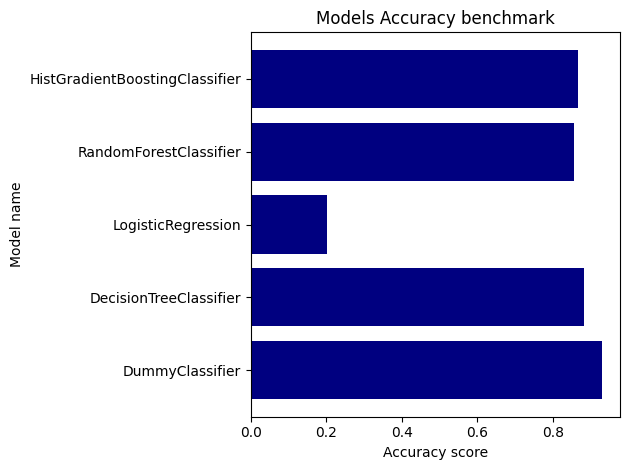

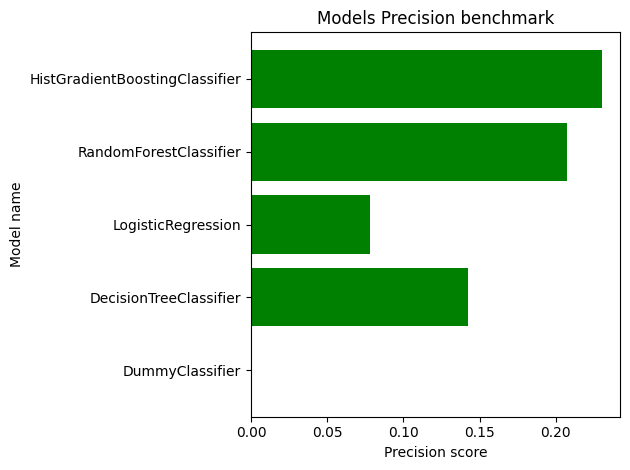

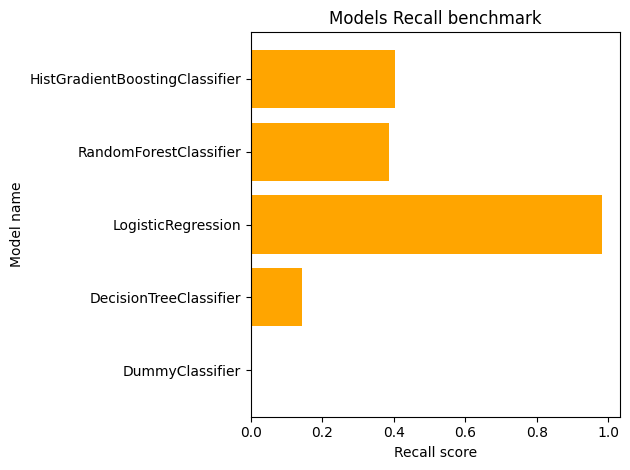

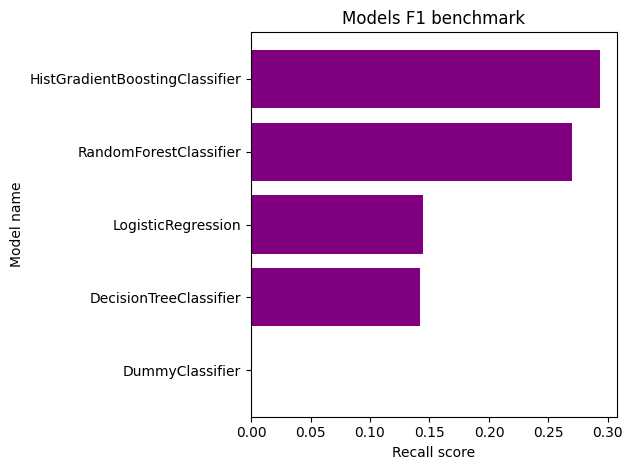

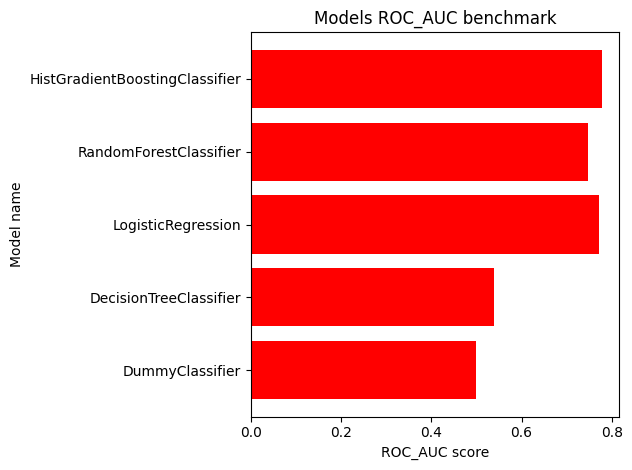

In [129]:
class ModelsPlot:
    def __init__(
        self,
        df_plot: object,
        columns: list[str],
        title_save: str,
        title: str,
        x_label: str,
        y_label: str,
        reverse_y_axis: bool = False,
        color: str = 'navy',
    ) -> None:
        """Method to initialisate show bar plot."""

        (
            self._df,
            self._columns,
            self._save_title,
            self._title,
            self._x_label,
            self._y_label,
            self._reverse_y_axis,
            self._color,
        ) = df_plot.copy(), columns, title_save, title, x_label, y_label, reverse_y_axis, color

        self.fig = plt.barh(
            self._df[self._columns[0]], self._df[self._columns[1]], color=self._color
        )
        ax = plt.gca()

        ax.set(title=self._title, xlabel=self._x_label, ylabel=self._y_label)
        if self._reverse_y_axis:
            ax.invert_yaxis()

        plt.tight_layout()
        plt.savefig(f'./assets/{self._save_title}')
        plt.show()

    def get_plot(self) -> object:
        """
        Get the current plot figure

        ## Returns
            Current plot figure.
        """
        return self.fig


plots: list[ModelsPlot] = [
    ModelsPlot(
        df_plot=results_df,
        columns=['model', 'Accuracy'],
        title_save='Model_Accuracy',
        title='Models Accuracy benchmark',
        x_label='Accuracy score',
        y_label='Model name',
        reverse_y_axis=True,
    ),
    ModelsPlot(
        df_plot=results_df,
        columns=['model', 'Precision'],
        title_save='Model_Precision',
        title='Models Precision benchmark',
        x_label='Precision score',
        y_label='Model name',
        reverse_y_axis=True,
        color='green',
    ),
    ModelsPlot(
        df_plot=results_df,
        columns=['model', 'Recall'],
        title_save='Model_Recall',
        title='Models Recall benchmark',
        x_label='Recall score',
        y_label='Model name',
        color='orange',
        reverse_y_axis=True,
    ),
    ModelsPlot(
        df_plot=results_df,
        columns=['model', 'F1'],
        title_save='Model_F1',
        title='Models F1 benchmark',
        x_label='Recall score',
        y_label='Model name',
        color='purple',
        reverse_y_axis=True,
    ),
    ModelsPlot(
        df_plot=results_df,
        columns=['model', 'ROC_AUC'],
        title_save='Model_ROC_AUC',
        title='Models ROC_AUC benchmark',
        x_label='ROC_AUC score',
        y_label='Model name',
        color='red',
        reverse_y_axis=True,
    ),
]

### 7.10 - **Filter models to get the best**

Filter the best model in a dictionary

In [130]:
top_1_model = {
    model_name: models_init[model_name] for model_name in results_df['model'].head(1).to_list()
}

### 7.11 - **Get the bests hyperparameters for the best model**

Create a function that takes a list of models as a parameter, and for each of them, it retrieves its best hyperparameters, then returns a list of the models retrained with the same, normally optimal, parameters. The subtlety here is that we will measure in advance, using ParameterGrid and the number of test sets we choose, the number of training/test runs that will need to be performed to find the best hyperparameters using GridSearchCV, and depending on this number, we will either use... If I understand correctly,

In [131]:
def tune_models(
    models: dict[str, dict], X_train: pd.DataFrame, y_train: pd.DataFrame
) -> dict[str, dict]:
    """
    Tune hyperparameters for each model config and return fitted best estimators.

    ## Parameters
        **models** : Dictionnary of models (instance, tunning...)
        **X_train** : X train dataset
        **y_train** : y train dataset

    ## Returns
        **Dictionnary** of tunned models
    """
    tuned_models = deepcopy(models)

    print('--------- Logs tuning --------')
    for name, model_data in tuned_models.items():
        pipe = Pipeline(steps=[('model', model_data.get('instance'))])

        param_grid = model_data.get('param_grid', {})

        if not param_grid:
            tuned_models[name]['instance'] = pipe.fit(X_train, y_train)
            continue

        n_candidates = len(ParameterGrid(param_grid))
        cv = 2
        n_fits = n_candidates * cv
        use_randomized = n_fits > 200

        print(
            f'{name} | {use_randomized and f"number of fits > 200 ({n_fits}), using RandomizedSearchCV" or f"number of fits <= 200 ({n_fits}), using GridSearchCV"} '
        )

        if use_randomized:
            search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=param_grid,
                n_iter=min(20, n_candidates),
                n_jobs=1,
                scoring='neg_mean_absolute_error',
                cv=cv,
                refit=True,
                random_state=42,
                verbose=True,
            )
        else:
            search = GridSearchCV(
                estimator=pipe,
                param_grid=param_grid,
                scoring='neg_mean_absolute_error',
                n_jobs=1,
                cv=cv,
                refit=True,
                verbose=True,
            )

        search.fit(X_train, y_train)
        tuned_models[name]['instance'] = search.best_estimator_

        print('------------------------------')

    return tuned_models

### 7.12 - **Last benchmark with the best hyperparameters**

We do another benchmark, this time with our 2 models trained with the optimal hyperparameters, and we display it as a dataframe.
But, we seen that this last benchmark can run 10 minutes, and at the end the HistGradientBoostingClassifier model has a lighter joblib file and same performances

In [132]:
tuned_models_last = tune_models(top_1_model, X_train_class, y_train_class)
models_last_benchmark = models_benchmark(
    tuned_models_last, X_test_class, y_test_class, X_train_class, y_train_class
)

results_df_last = (
    pd.DataFrame(models_last_benchmark)
    .sort_values(
        by=['F1', 'Recall', 'Precision', 'Accuracy'], ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)
top_2_best_model = results_df_last.head(2)
best_model = tuned_models_last[results_df_last.head(1)['model'].values[0]]['instance']

print(results_df_last)

--------- Logs tuning --------
HistGradientBoostingClassifier | number of fits <= 200 (32), using GridSearchCV 
Fitting 2 folds for each of 16 candidates, totalling 32 fits
------------------------------
                            model  Accuracy  Precision    Recall        F1  \
0  HistGradientBoostingClassifier  0.867087   0.230828  0.402156  0.293306   

    ROC_AUC  
0  0.778221  


### 7.13 - **Export best model with joblib**

We can now take the model with the best scores, and export it as a .joblib, so that it can be imported into the python file which will create the interactive streamlit dashboard, and thus make predictions.

In [ ]:
print(f'The best model is : {results_df_last.head(1)["model"].values[0]}\n')
print(
    f'Final evaluation : {models_benchmark({results_df_last.head(1)["model"].values[0]: tuned_models_last[results_df_last.head(1)["model"].values[0]]}, X_test_class, y_test_class, X_train_class, y_train_class)[0]}\n'
)
print('Exporting...')

save_data = {
    'model': best_model,
}

joblib.dump(save_data, './models/model.joblib')

The best model is : HistGradientBoostingClassifier

Final evaluation : {'model': 'HistGradientBoostingClassifier', 'Accuracy': 0.867087058469123, 'Precision': 0.23082843464032482, 'Recall': 0.4021560097981248, 'F1': 0.29330591940613426, 'ROC_AUC': 0.7782205157986741}

Exporting...


['model.joblib']

### 7.14 - **Setup and usage example**

In [134]:
def build_features_for_user_product(
    user_id: int,
    product_id: int,
    orders: pd.DataFrame,
    order_product: pd.DataFrame,
    products: pd.DataFrame,
) -> dict:
    """
    Predict whether a user will reorder a product in their next order.

    # Parameters
        **user_id** : User identifier
        **product_id** : Product identifier
        **orders** : pd.DataFrame, must contain at least: ['order_id', 'user_id', 'order_number', 'order_hour_of_day', 'days_since_prior_order']
        **order_product** : pd.DataFrame, must contain at least: ['order_id', 'product_id', 'add_to_cart_order']
        **products** : pd.DataFrame, must contain at least: ['product_id', 'aisle_id', 'department_id']

    #Returns
        dict of prediction payload with probability and binary prediction.
    """

    user_orders = orders.loc[orders['user_id'] == user_id].copy()

    if user_orders.empty:
        raise ValueError(f'user_id = {user_id} not found in orders.')

    product_row = products.loc[products['product_id'] == product_id]

    if product_row.empty:
        raise ValueError(f'product_id = {product_id} not found in products.')

    user_orders = user_orders.dropna(subset=['order_id', 'user_id', 'order_number']).copy()
    user_orders = user_orders.sort_values('order_number').copy()
    user_orders['days_since_prior_order'] = user_orders['days_since_prior_order'].fillna(0)

    user_order_ids = user_orders['order_id'].unique()

    user_order_products = order_product.loc[order_product['order_id'].isin(user_order_ids)].copy()

    user_history = user_order_products.merge(
        user_orders[
            ['order_id', 'user_id', 'order_number', 'order_hour_of_day', 'days_since_prior_order']
        ],
        on='order_id',
        how='inner',
    )

    user_history = user_history.merge(
        products[['product_id', 'aisle_id', 'department_id']],
        on='product_id',
        how='left',
    )

    user_product_history = user_history.loc[user_history['product_id'] == product_id].copy()
    if user_product_history.empty:
        raise ValueError(f'user_id={user_id} has never bought product_id={product_id}.')

    user_product_count = int(len(user_product_history))

    user_total_orders = int(user_orders['order_id'].nunique())

    user_product_order_ratio = (
        user_product_count / user_total_orders if user_total_orders > 0 else 0.0
    )

    last_order_number = int(user_orders['order_number'].max())
    last_product_order_number = int(user_product_history['order_number'].max())
    orders_since_last_purchase = int(last_order_number - last_product_order_number)

    avg_add_to_cart_order = float(user_product_history['add_to_cart_order'].mean())

    basket_sizes = user_order_products.groupby('order_id').size()
    avg_basket_size = float(basket_sizes.mean())

    user_orders['cumulative_days'] = user_orders['days_since_prior_order'].cumsum()

    user_product_days = (
        user_product_history.merge(
            user_orders[['order_id', 'cumulative_days']],
            on='order_id',
            how='left',
            suffixes=('', '_dup'),
        )[['order_id', 'cumulative_days']]
        .drop_duplicates()
        .sort_values('cumulative_days')
    )

    days_between = user_product_days['cumulative_days'].diff()

    has_multiple_purchases = bool(days_between.notna().any())

    if has_multiple_purchases:
        avg_days_between_user_product_orders = float(days_between.mean())
    else:
        avg_days_between_user_product_orders = -1.0

    avg_order_hour_for_user_product = float(user_product_history['order_hour_of_day'].mean())

    user_avg_days_between_orders = float(user_orders['days_since_prior_order'].mean())

    all_product_orders = order_product.loc[order_product['product_id'] == product_id].copy()
    all_product_orders = all_product_orders.merge(
        orders[['order_id', 'user_id']],
        on='order_id',
        how='inner',
    )

    product_user_counts = all_product_orders.groupby('user_id').size().reset_index(name='count')

    user_bought = int(product_user_counts['user_id'].nunique())
    user_reordered = int((product_user_counts['count'] > 1).sum())

    product_reorder_ratio = user_reordered / user_bought if user_bought > 0 else 0.0

    total_order_product_rows = len(order_product)
    product_total_purchases = int((order_product['product_id'] == product_id).sum())
    product_total_purchases_ratio = (
        product_total_purchases / total_order_product_rows if total_order_product_rows > 0 else 0.0
    )

    aisle_id = int(product_row['aisle_id'].iloc[0])
    department_id = int(product_row['department_id'].iloc[0])

    row = {
        'aisle_id': aisle_id,
        'department_id': department_id,
        'user_product_count': user_product_count,
        'user_total_orders': user_total_orders,
        'user_product_order_ratio': user_product_order_ratio,
        'orders_since_last_purchase': orders_since_last_purchase,
        'avg_add_to_cart_order': avg_add_to_cart_order,
        'avg_basket_size': avg_basket_size,
        'avg_days_between_user_product_orders': avg_days_between_user_product_orders,
        'has_multiple_purchases': has_multiple_purchases,
        'df_avg_ordr_hour_for_user_pr': avg_order_hour_for_user_product,
        'user_avg_days_between_orders': user_avg_days_between_orders,
        'product_reorder_ratio': product_reorder_ratio,
        'product_total_purchases_ratio': product_total_purchases_ratio,
    }

    X_one = pd.DataFrame([row])

    return X_one

In [ ]:
def predict_next_reorder_for_user_product(
    model,
    user_id: int,
    product_id: int,
    orders: pd.DataFrame,
    order_product: pd.DataFrame,
    products: pd.DataFrame,
    threshold: float = 0.15,
):
    """
    Predict when if customer will reorder the product.

    # Parameters
        **model** : Model instance
        **user_id** : User unique identifier
        **product_id** : Product unique identifier
        **orders : Orders dataset
        **order_product** : Order products dataset
        **products** : Products dataset
        **threshold** : Prediction threshold

    # Returns
        Dict of : User id, product id, prediction and features used list
    """

    X_one = build_features_for_user_product(
        user_id=user_id,
        product_id=product_id,
        orders=orders,
        order_product=order_product,
        products=products,
    )
    proba = float(model.predict_proba(X_one)[:, 1][0])
    pred = int(proba >= threshold)

    return {
        'user_id': user_id,
        'product_id': product_id,
        'probability_reorder_next_order': proba,
        'threshold': threshold,
        'prediction': pred,
        'features_used': X_one.iloc[0].to_dict(),
    }

In [ ]:
def load_my_model(model_name: str = './models/model.joblib') -> tuple[object, list, float]:
    """
    Get the exported data from a joblib file

    # Parameters
        **model_name** : The model name

    # Returns
        **(model, feature_comumns, best_threshold)** : Tuple of imported data
    """

    bundle = joblib.load(model_name)
    model = bundle['model']

    return model


model = load_my_model()

In [137]:
result = predict_next_reorder_for_user_product(
    model=model,
    user_id=1,
    product_id=196,
    orders=orders,
    order_product=order_product,
    products=products,
    threshold=0.15,
)

print(result)

{'user_id': 1, 'product_id': 196, 'probability_reorder_next_order': 0.3580124503849537, 'threshold': 0.15, 'prediction': 1, 'features_used': {'aisle_id': 77, 'department_id': 7, 'user_product_count': 7, 'user_total_orders': 7, 'user_product_order_ratio': 1.0, 'orders_since_last_purchase': 0, 'avg_add_to_cart_order': 1.4285714285714286, 'avg_basket_size': 6.285714285714286, 'avg_days_between_user_product_orders': 20.5, 'has_multiple_purchases': True, 'df_avg_ordr_hour_for_user_pr': 10.428571428571429, 'user_avg_days_between_orders': 17.571428571428573, 'product_reorder_ratio': 0.49767095211477547, 'product_total_purchases_ratio': 0.0010950211664655647}}


## 8 - Can we predict how many days after their last observed order a customer will purchase a given product again?

### 8.1 - Target

In [138]:
df_client_product_reg = df_client_product.loc[df_client_product['target'] == 1].copy()

df_target = last_order.merge(last_order_products, on='order_id')[
    ['user_id', 'product_id', 'days_since_prior_order']
].drop_duplicates()
df_target['target_days'] = df_target['days_since_prior_order']

df_client_product_reg = df_client_product_reg.merge(
    df_target[['user_id', 'product_id', 'target_days']], how='left', on=['user_id', 'product_id']
)
df_client_product_cleaned_reg = df_client_product_reg.copy().dropna()

In [139]:
print(df_client_product_cleaned_reg)

X_reg = df_client_product_cleaned_reg.drop(
    ['user_id', 'product_id', 'target', 'target_days'], axis=1
).copy()
y_reg = df_client_product_cleaned_reg['target_days'].copy()

print(X_reg.shape, y_reg.shape)

        user_id  product_id  aisle_id  department_id  user_product_count  \
0             1         196        77              7                   6   
1             1       10258       117             19                   5   
2             1       12427        23             19                   6   
3             1       13032       121             14                   1   
4             1       25133        21             16                   4   
...         ...         ...       ...            ...                 ...   
474006   206201       23909        84             16                   9   
474007   206201       34024        77              7                   5   
474008   206201       39612         2             16                   1   
474009   206205       27845        84             16                   1   
474010   206206       45139        89             13                   1   

        user_total_orders  user_product_order_ratio  \
0                       6       

### 8.2 - Split datasets

In [140]:
X_train_full_reg, X_test_reg, y_train_full_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42,
)

X_train_reg, _, y_train_reg, _ = train_test_split(
    X_train_full_reg,
    y_train_full_reg,
    train_size=200_000,
    random_state=42,
)

print(X_test_reg, y_test_reg)
print(X_train_reg, y_train_reg)

        aisle_id  department_id  user_product_count  user_total_orders  \
74128         83              4                   1                  5   
33864         31              7                   1                  1   
124165        84             16                   2                  9   
194695       110             13                   6                 10   
24803         94              7                   1                  5   
...          ...            ...                 ...                ...   
61855        123              4                   2                  2   
242369        24              4                   3                  8   
146542        24              4                   1                  2   
76037         83              4                   3                 27   
147627        24              4                   2                 12   

        user_product_order_ratio  orders_since_last_purchase  \
74128                   0.200000               

### 8.3 - Models initialisation

In [141]:
models_init_reg = {
    'RandomForestRegressor': {
        'instance': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1),
        'param_grid': {
            'model__n_estimators': [50, 75],
            'model__max_depth': [10, 15],
            'model__min_samples_leaf': [5],
        },
    },
    'ExtraTreesRegressor': {
        'instance': ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=1),
        'param_grid': {},
    },
    'DummyRegressor': {'instance': DummyRegressor(strategy='mean'), 'param_grid': {}},
    'LinearRegression': {'instance': LinearRegression(), 'param_grid': {}},
    'HuberRegressor': {'instance': HuberRegressor(max_iter=1000), 'param_grid': {}},
    'Ridge': {'instance': Ridge(alpha=1.0), 'param_grid': {}},
    'ElasticNet': {
        'instance': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=5000),
        'param_grid': {},
    },
    'DecisionTreeRegressor': {
        'instance': DecisionTreeRegressor(random_state=42, max_depth=8),
        'param_grid': {},
    },
    'GradientBoostingRegressor': {
        'instance': GradientBoostingRegressor(random_state=42),
        'param_grid': {},
    },
    'AdaBoostRegressor': {'instance': AdaBoostRegressor(random_state=42), 'param_grid': {}},
    'KNeighborsRegressor': {'instance': KNeighborsRegressor(n_neighbors=5), 'param_grid': {}},
}

### 8.4 - First models benchmark

In [142]:
models_first_benchmark = models_benchmark(
    models_init_reg, X_test_reg, y_test_reg, X_train_reg, y_train_reg, target_type='regression'
)

results_df_reg = (
    pd.DataFrame(models_first_benchmark)
    .sort_values(by=['MAE', 'RMSE', 'R2'], ascending=[True, True, False])
    .reset_index(drop=True)
)
top_5_best_model = results_df_reg.head(5)

print(results_df_reg)

                        model       MAE      RMSE        R2
0       RandomForestRegressor  5.647117  7.313339  0.398808
1         ExtraTreesRegressor  6.033868  7.661515  0.340202
2   GradientBoostingRegressor  6.655511  8.191811  0.245705
3       DecisionTreeRegressor  6.657333  8.229418  0.238763
4              HuberRegressor  6.875218  8.599517  0.168754
5                       Ridge  7.039100  8.501164  0.187659
6            LinearRegression  7.039206  8.501294  0.187634
7                  ElasticNet  7.115845  8.527942  0.182533
8         KNeighborsRegressor  7.311340  9.142002  0.060571
9           AdaBoostRegressor  7.358331  8.607353  0.167238
10             DummyRegressor  8.028289  9.432130 -0.000003


### 8.5 - Show models performance metrics

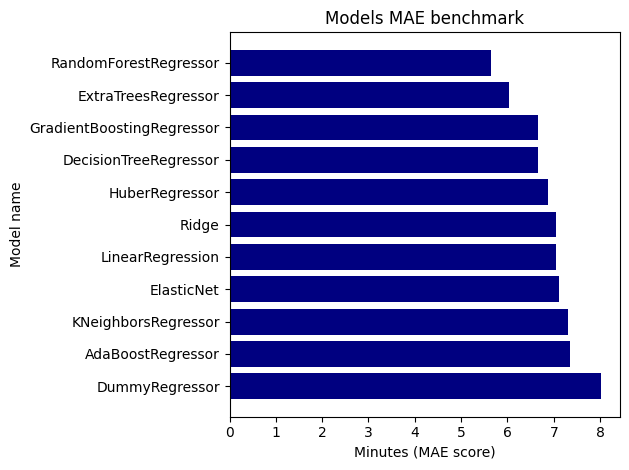

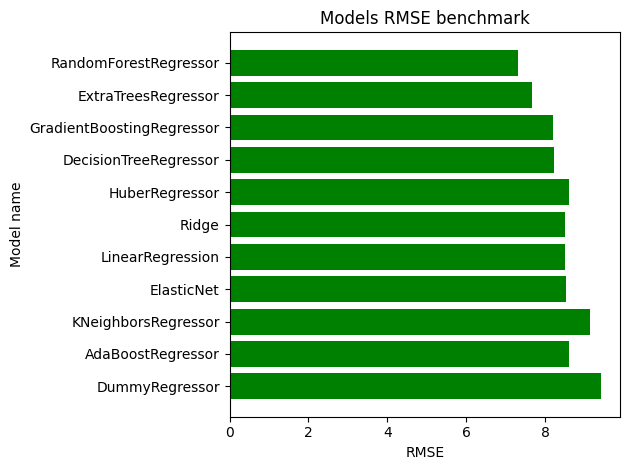

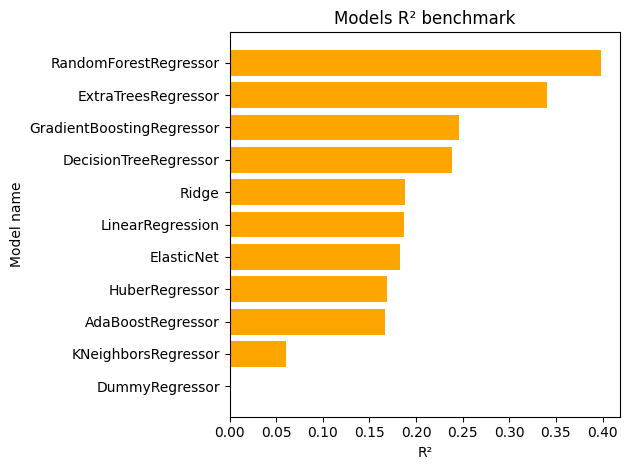

In [143]:
plots: list[ModelsPlot] = [
    ModelsPlot(
        df_plot=results_df_reg,
        columns=['model', 'MAE'],
        title_save='Model_MAE_FIRST',
        title='Models MAE benchmark',
        x_label='Minutes (MAE score)',
        y_label='Model name',
        reverse_y_axis=True,
    ),
    ModelsPlot(
        df_plot=results_df_reg,
        columns=['model', 'RMSE'],
        title_save='Model_RMSE_FIRST',
        title='Models RMSE benchmark',
        x_label='RMSE',
        y_label='Model name',
        reverse_y_axis=True,
        color='green',
    ),
    ModelsPlot(
        df_plot=results_df_reg.sort_values(by=['R2']),
        columns=['model', 'R2'],
        title_save='Model_R²_FIRST',
        title='Models R² benchmark',
        x_label='R²',
        y_label='Model name',
        color='orange',
    ),
]

### 8.6 - Get the best model

In [144]:
top_1_model_reg = {
    model_name: models_init_reg[model_name]
    for model_name in results_df_reg['model'].head(1).to_list()
}

### 8.7 - Tune the best model

In [ ]:
tuned_models_last_reg = tune_models(top_1_model_reg, X_train_reg, y_train_reg)
models_last_benchmark_reg = models_benchmark(
    tuned_models_last_reg,
    X_test_reg,
    y_test_reg,
    X_train_reg,
    y_train_reg,
    target_type='regression',
)

results_df_last_reg = (
    pd.DataFrame(models_last_benchmark_reg)
    .sort_values(by=['MAE', 'RMSE', 'R2'])
    .reset_index(drop=True)
)
best_model = tuned_models_last_reg[results_df_last_reg.head(1)['model'].values[0]]['instance']

print(results_df_last_reg)

--------- Logs tuning --------
RandomForestRegressor | number of fits <= 200 (8), using GridSearchCV 
Fitting 2 folds for each of 4 candidates, totalling 8 fits


### 8.8 - Model exportation

In [ ]:
print(f'The best model is : {results_df_last_reg.head(1)["model"].values[0]}\n')
print(
    f'Final evaluation : {evaluate_model(y_test_reg, best_model.predict(X_test_reg), target_type="regression")}\n'
)
print('Exporting...')

export_data = {
    'model': best_model,
}

joblib.dump(export_data, './models/model_regression.joblib')

The best model is : RandomForestRegressor

Final evaluation : {'MAE': 6.087078735861977, 'RMSE': 7.670373033535978, 'R2': 0.33867564136481765}

Exporting...


['model_regression.joblib']

In [ ]:
def predict_days_until_next_reorder_for_user_product(
    model,
    user_id: int,
    product_id: int,
    orders: pd.DataFrame,
    order_product: pd.DataFrame,
    products: pd.DataFrame,
):
    """
    Predict when customer will reorder the product.

    # Parameters
        **model** : Model instance
        **user_id** : User unique identifier
        **product_id** : Product unique identifier
        **orders : Orders dataset
        **order_product** : Order products dataset
        **products** : Products dataset

    # Returns
        Dict of : User id, product id, prediction and features used list
    """
    X_one = build_features_for_user_product(
        user_id=user_id,
        product_id=product_id,
        orders=orders,
        order_product=order_product,
        products=products,
    )
    pred_days = float(model.predict(X_one)[0])

    return {
        'user_id': user_id,
        'product_id': product_id,
        'prediction': pred_days,
        'features_used': X_one.iloc[0].to_dict(),
    }

In [ ]:
result = predict_days_until_next_reorder_for_user_product(
    model=joblib.load('./models/model_regression.joblib'),
    user_id=1,
    product_id=196,
    orders=orders,
    order_product=order_product,
    products=products,
)

print(result)

{'user_id': 1, 'product_id': 196, 'probability_reorder_next_order': 0.3580124503849537, 'threshold': 0.15, 'prediction': 1, 'features_used': {'aisle_id': 77, 'department_id': 7, 'user_product_count': 7, 'user_total_orders': 7, 'user_product_order_ratio': 1.0, 'orders_since_last_purchase': 0, 'avg_add_to_cart_order': 1.4285714285714286, 'avg_basket_size': 6.285714285714286, 'avg_days_between_user_product_orders': 20.5, 'has_multiple_purchases': True, 'df_avg_ordr_hour_for_user_pr': 10.428571428571429, 'user_avg_days_between_orders': 17.571428571428573, 'product_reorder_ratio': 0.49767095211477547, 'product_total_purchases_ratio': 0.0010950211664655647}}
